In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [11]:
class BatsMan(TypedDict):
    run:int
    ball:int
    four:int
    six:int

    sr:float
    bpb:float
    boundary_percent:float
    summary:str
    


In [12]:
def cal_sr(state:BatsMan):
    sr = (state['run']/state['ball'])*100
    
    return {'sr': sr}




In [13]:
def calculate_bpb(state: BatsMan):

    bpb = state['ball']/(state['four'] + state['six'])

    return {'bpb': bpb}

In [14]:
def calculate_boundary_percent(state: BatsMan):

    boundary_percent = (((state['four'] * 4) + (state['six'] * 6))/state['run'])*100

    return {'boundary_percent': boundary_percent}

In [15]:
def summary(state: BatsMan):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""
    
    return {'summary': summary}

In [16]:
graph = StateGraph(BatsMan)
graph.add_node('cal_sr',cal_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('summary',summary)

graph.add_edge(START,'cal_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('cal_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundary_percent','summary')
graph.add_edge('summary', END)

workflow=graph.compile()

               


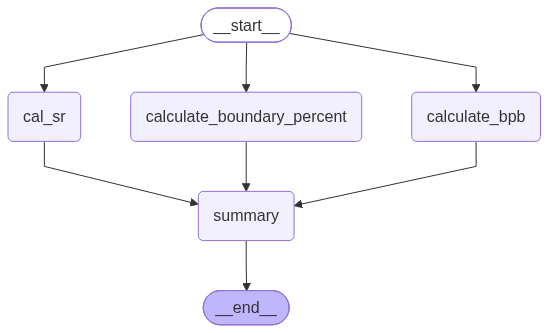

In [17]:
workflow

In [18]:
intial_state = {
    'run': 200,
    'ball': 60,
    'four': 6,
    'six': 6
}

workflow.invoke(intial_state)

{'run': 200,
 'ball': 60,
 'four': 6,
 'six': 6,
 'sr': 333.33333333333337,
 'bpb': 5.0,
 'boundary_percent': 30.0,
 'summary': '\nStrike Rate - 333.33333333333337 \n\nBalls per boundary - 5.0 \n\nBoundary percent - 30.0\n'}